<a href="https://colab.research.google.com/github/KDNaigan/KD/blob/main/Naigan_Hands_on_Activity_1_1_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Activity 1.1 : Introduction to Machine Learning

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Objective(s):

This activity aims to introduce how to use the different toolsets  in machine learning.

Intended Learning Outcomes (ILOs):
* Demonstrate how to use different toolsets in machine learning.
* Demonstrate how to import, manipulate and analyze data using pandas and numpy.
* Demonstrate how to visualize data in graphs using matplotlib and seaborn


Resources:
* Jupyter Notebook
* Iris_Data.csv


Procedure:

The iris data set will be used for this activity. It is a well-known data set containing iris species and sepal and petal measurements.

Import the libraries and the dataset

In [ ]:
#import the libraries
import pandas as pd
import numpy as np

# import the dataset
data = pd.read_csv('/content/drive/MyDrive/DATA SCI 2/Iris_Data.csv')
#check the content of the dataframe
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


Determine the following:
* The number of data points (rows).
* The column names.
* The data types for each column.

In [ ]:
#the number of datapoints
print(data.shape[0])

#the column names
print(data.columns.tolist())

#the data types for each column
print(data.dtypes)

150
['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


Examine the species names and note that they all begin with 'Iris-'. Remove this portion of the name so the species name is shorter.

In [ ]:
#remove the 'Iris-' portion of the name
data['species'] = data.species.str.replace('Iris-', '')
data.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Determine the following:
* The number of each species present.
* The mean, median, and quantiles and ranges (max-min) for each petal and sepal measurement.

In [ ]:
#the number of each species present
data.species.value_counts()

# the mean, median and quartiles and ranges
stats_df = data.describe()
stats_df.loc['range'] = stats_df.loc['max'] - stats_df.loc['min']

out_fields = ['mean','25%','50%','75%', 'range']
stats_df = stats_df.loc[out_fields]
stats_df.rename({'50%': 'median'}, inplace=True)
stats_df



,sepal_length,sepal_width,petal_length,petal_width
mean,5.843333,3.054,3.758667,1.198667
25%,5.100000,2.800,1.600000,0.300000
median,5.800000,3.000,4.350000,1.300000
75%,6.400000,3.300,5.100000,1.800000
range,3.600000,2.400,5.900000,2.400000


Calculate the following for each species in a separate dataframe:
* The mean of each measurement (sepal_length, sepal_width, petal_length, and petal_width).
* The median of each of these measurements.

In [ ]:
# The mean calculation
data.groupby('species').mean()



,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.418,1.464,0.244
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


In [ ]:
# The median calculation
data.groupby('species').median()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.0,3.4,1.50,0.2
versicolor,5.9,2.8,4.35,1.3
virginica,6.5,3.0,5.55,2.0


In [ ]:
from pprint import pprint

agg_dict = {field: ['mean', 'median'] for field in data.columns if field != 'species'}
agg_dict['petal_length'] = 'max'
pprint(agg_dict)
data.groupby('species').agg(agg_dict)

{'petal_length': 'max',
 'petal_width': ['mean', 'median'],
 'sepal_length': ['mean', 'median'],
 'sepal_width': ['mean', 'median']}


sepal_length        sepal_width        petal_length petal_width  \
                   mean median        mean median          max        mean   
species                                                                      
setosa            5.006    5.0       3.418    3.4          1.9       0.244   
versicolor        5.936    5.9       2.770    2.8          5.1       1.326   
virginica         6.588    6.5       2.974    3.0          6.9       2.026   

                   
           median  
species            
setosa        0.2  
versicolor    1.3  
virginica     2.0

Make a scatter plot of `sepal_length` vs `sepal_width` using Matplotlib. Label the axes and give the plot a title.

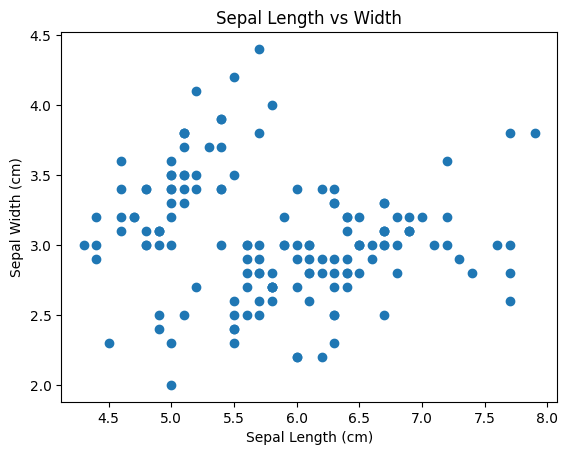

In [ ]:
#Scatter plot of sepal_length versus sepal_width using Matplotlib

import matplotlib.pyplot as plt
%matplotlib inline
# A simple scatter plot with Matplotlib
ax = plt.axes()

ax.scatter(data.sepal_length, data.sepal_width)

# Label the axes
ax.set(xlabel='Sepal Length (cm)',
       ylabel='Sepal Width (cm)',
       title='Sepal Length vs Width');


Interpret the result of the scatter plot.

To spread out of data points

Make a histogram of any one of the four features. Label axes and title it as appropriate. What is the function of the histogram ?

It is the frequency of how much the data points comes out

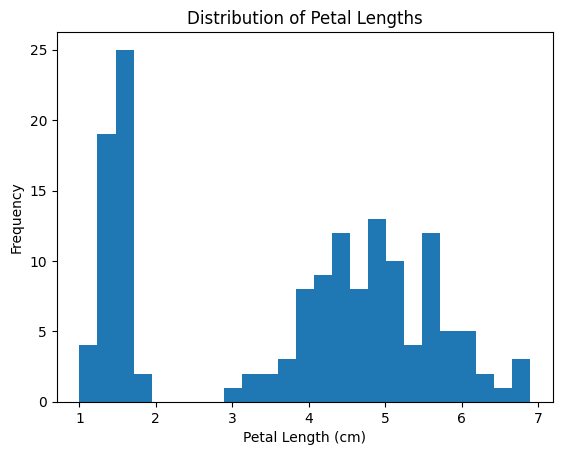

In [ ]:
#histogram
ax = plt.axes()
ax.hist(data.petal_length, bins=25);

ax.set(xlabel='Petal Length (cm)',
       ylabel='Frequency',
       title='Distribution of Petal Lengths');

Make a boxplot of each petal and sepal measurement. What is the function of the boxplot?

It displays the distribution of data based in each petal and sepal measurement

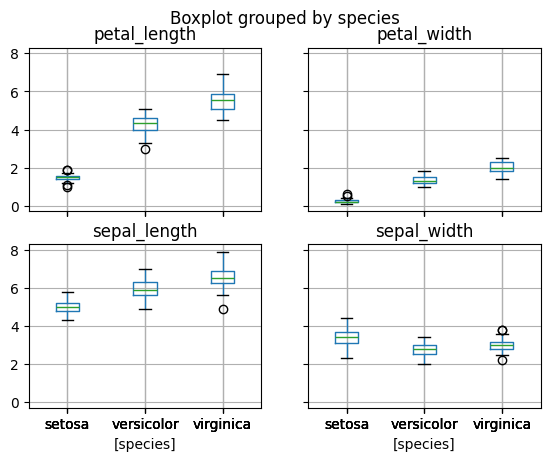

In [ ]:
#boxplot
data.boxplot(by='species');

Make a single boxplot where the features are separated in the x-axis and species are colored with different hues.

In [ ]:
#single boxplot
plot_data = (data
             .set_index('species')
             .stack()
             .to_frame()
             .reset_index()
             .rename(columns={0:'size', 'level_1':'measurement'})
            )

plot_data.head()

,species,measurement,size
0,setosa,sepal_length,5.1
1,setosa,sepal_width,3.5
2,setosa,petal_length,1.4
3,setosa,petal_width,0.2
4,setosa,sepal_length,4.9


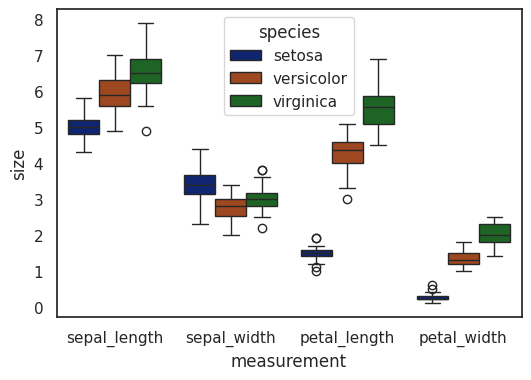

In [ ]:
import seaborn as sns
sns.set_style('white')
sns.set_context('notebook')
sns.set_palette('dark')

f = plt.figure(figsize=(6,4))
sns.boxplot(x='measurement', y='size',
            hue='species', data=plot_data);

Make a pairplot with Seaborn to examine the correlation between each of the measurements.

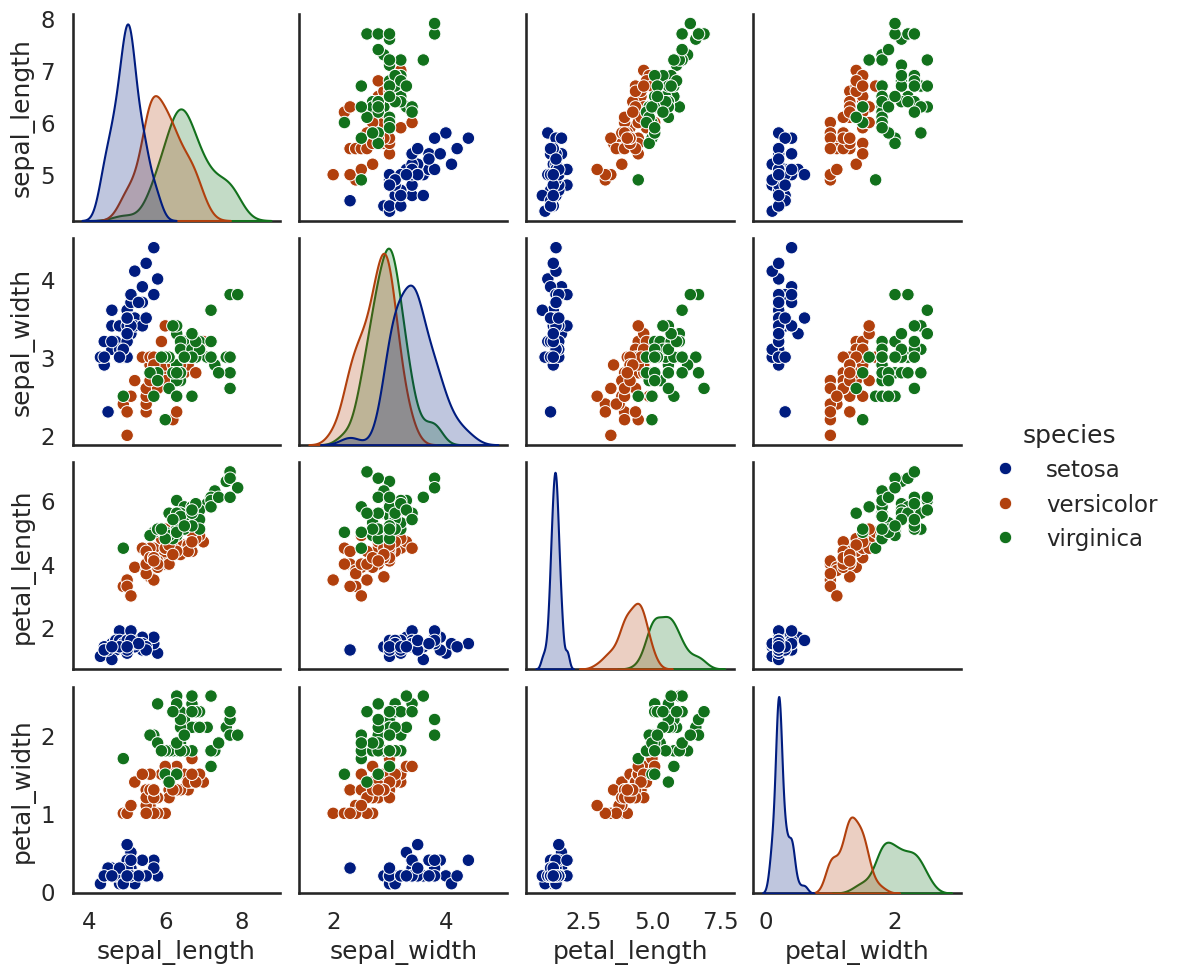

In [ ]:
#pair plot
sns.set_context('talk')
sns.pairplot(data, hue='species');



Interpret the result of correlation using the pairplot



This demonstrates the relationships and correlations between all pairs of numerical features in the Iris dataset

Supplementary Activity:
* Choose your own dataset
* Import the dataset
* Determine the number of datapoints, columns and data types
* Remove unneccesary columns
* Do data cleaning such as removing empty values.
* Perform descriptive statistics such as mean, median and mode
* Compare and analyze your data using data visualization

In [ ]:
#import the libraries
import pandas as pd
import numpy as np

# import the dataset
data = pd.read_csv('/content/drive/MyDrive/student_exam_scores.csv')
#check the content of the dataframe
data.head()

,student_id,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
0,S001,8.0,8.8,72.1,45,30.2
1,S002,1.3,8.6,60.7,55,25.0
2,S003,4.0,8.2,73.7,86,35.8
3,S004,3.5,4.8,95.1,66,34.0
4,S005,9.1,6.4,89.8,71,40.3


# DETERMINE THE NUMBER OF DATAPOINTS, COLUMNS AND DATA TYPES

In [ ]:
#the number of datapoints
print(data.shape[0])

#the column names
print(data.columns.tolist())

#the data types for each column
print(data.dtypes)

200
['student_id', 'hours_studied', 'sleep_hours', 'attendance_percent', 'previous_scores', 'exam_score']
student_id             object
hours_studied         float64
sleep_hours           float64
attendance_percent    float64
previous_scores         int64
exam_score              int64
dtype: object


In [ ]:
data['student_id'] = data.student_id.str.replace('S', '')
data['exam_score'] = data.exam_score.round()
data['exam_score'] = data['exam_score'].astype(int)
data.head()

,student_id,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
0,001,8.0,8.8,72.1,45,30
1,002,1.3,8.6,60.7,55,25
2,003,4.0,8.2,73.7,86,36
3,004,3.5,4.8,95.1,66,34
4,005,9.1,6.4,89.8,71,40


In [ ]:
data.exam_score.value_counts()
#MEAN, MEDIAN, RANGE AND QUARTILES OF DATA
data.df = data.describe()
data.df.loc['range'] = data.df.loc['max'] - data.df.loc['min']
out_fields = ['mean','25%','50%','75%','range']
data.df = data.df.loc[out_fields]
data.df.rename(({'50%': 'median'}), inplace=True)
data.df


,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
mean,6.3255,6.622,74.830,66.8,33.955
25%,3.5000,5.300,62.200,54.0,30.000
median,6.1500,6.700,75.250,67.5,34.000
75%,9.0000,8.025,87.425,80.0,39.000
range,11.0000,5.000,49.700,55.0,34.000


# MEAN AND MEDIAN CALCULATIONS



In [ ]:
data.drop('student_id', axis=1).groupby('exam_score').mean()

,hours_studied,sleep_hours,attendance_percent,previous_scores
exam_score,,,,
17,1.100000,5.500000,53.600000,65.000000
18,2.000000,4.300000,75.800000,55.000000
19,3.000000,5.050000,54.850000,53.500000
21,2.150000,6.100000,76.500000,47.000000
22,3.950000,6.550000,57.700000,54.500000
23,3.560000,7.540000,74.880000,46.400000
24,3.000000,4.900000,64.320000,61.400000
25,2.420000,7.460000,65.780000,60.000000
26,3.271429,6.214286,83.628571,55.714286


In [ ]:
data.drop('student_id', axis=1).groupby('exam_score').median()

,hours_studied,sleep_hours,attendance_percent,previous_scores
exam_score,,,,
17,1.10,5.50,53.60,65.0
18,2.00,4.30,75.80,55.0
19,3.00,5.05,54.85,53.5
21,2.15,6.10,76.50,47.0
22,3.95,6.55,57.70,54.5
23,3.10,8.00,68.90,47.0
24,3.50,4.90,56.80,59.0
25,1.80,7.60,66.80,58.0
26,3.20,5.40,92.80,58.0


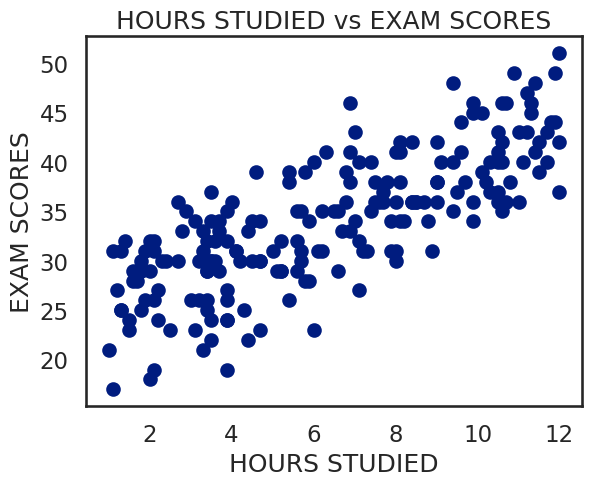

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
# A simple scatter plot with Matplotlib
ax = plt.axes()

ax.scatter(data.hours_studied, data.exam_score)
# Label the axes
ax.set(xlabel='Hours Studied',
       ylabel='Exam Scores',
       title='Hours Studied vs Exam Scores');


I create a scatter plot of Hours Studied vs Exam Scores to visually explore the relationship between these two variables

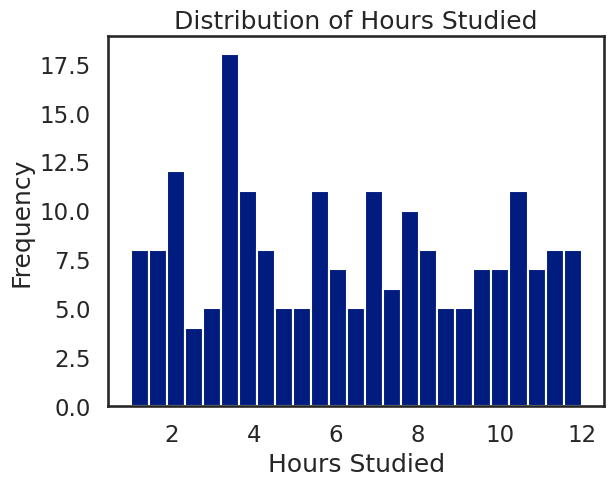

In [ ]:
#histogram
ax = plt.axes()
ax.hist(data.hours_studied, bins=25);

ax.set(xlabel='Hours Studied',
       ylabel='Frequency',
       title='Distribution of Hours Studied');

This histogram is to visualize the distribution of 'Hours Studied' among the students. It also helps to understand the range and shape of how students study hours are spread out.

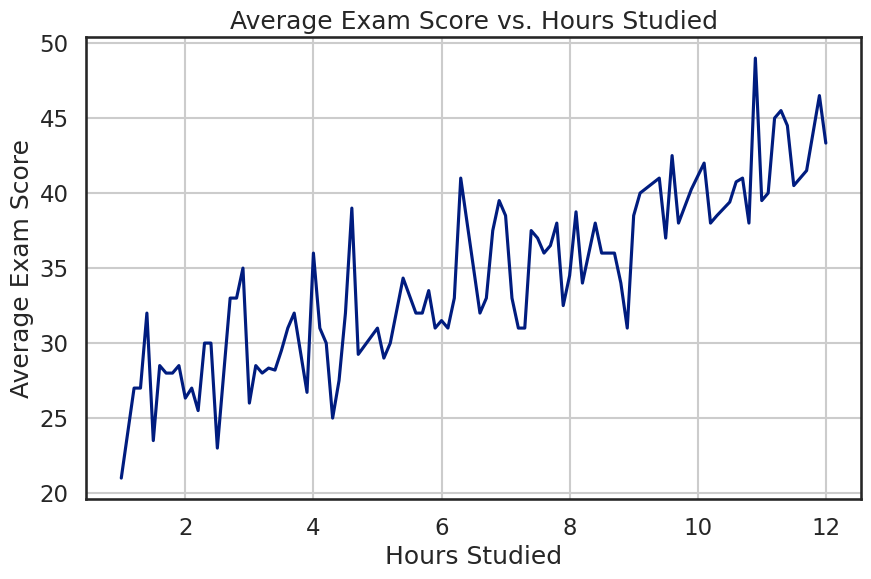

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the mean exam_score for each hours studied
mean_scores_by_hours = data.groupby('hours_studied')['exam_score'].mean().reset_index()

# Create the line plot
plt.figure(figsize=(10, 6))
sns.lineplot(x='hours_studied', y='exam_score', data=mean_scores_by_hours)
plt.title('Average Exam Score vs. Hours Studied')
plt.xlabel('Hours Studied')
plt.ylabel('Average Exam Score')
plt.grid(True)
plt.show()

This line plot is to visualize the trend of how the average exam score changes as the number of studied hours increases

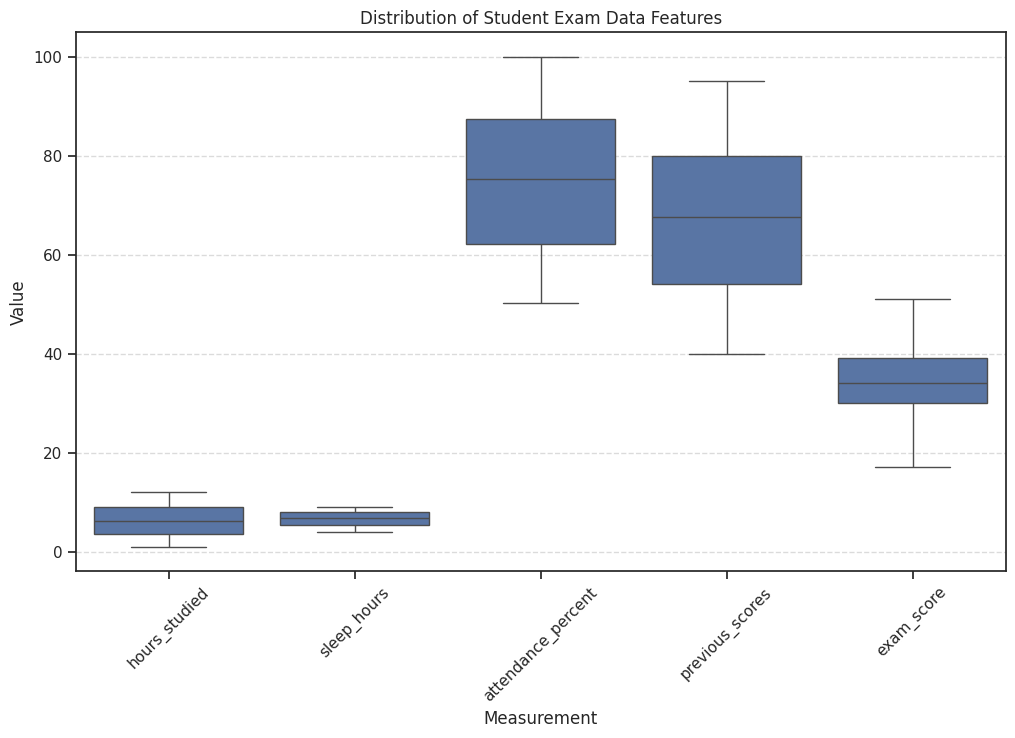

In [126]:
import seaborn as sns
import matplotlib.pyplot as plt

# Identify numerical columns to plot
numerical_cols = ['hours_studied', 'sleep_hours', 'attendance_percent', 'previous_scores', 'exam_score']

plot_data_student = data[numerical_cols].melt(var_name='measurement', value_name='value')

plt.figure(figsize=(12, 7))
sns.boxplot(x='measurement', y='value', data=plot_data_student)
plt.title('Distribution of Student Exam Data Features')
plt.xlabel('Measurement')
plt.ylabel('Value')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

This box plot represent the spread and central tendency of key metrics related to the student performance.

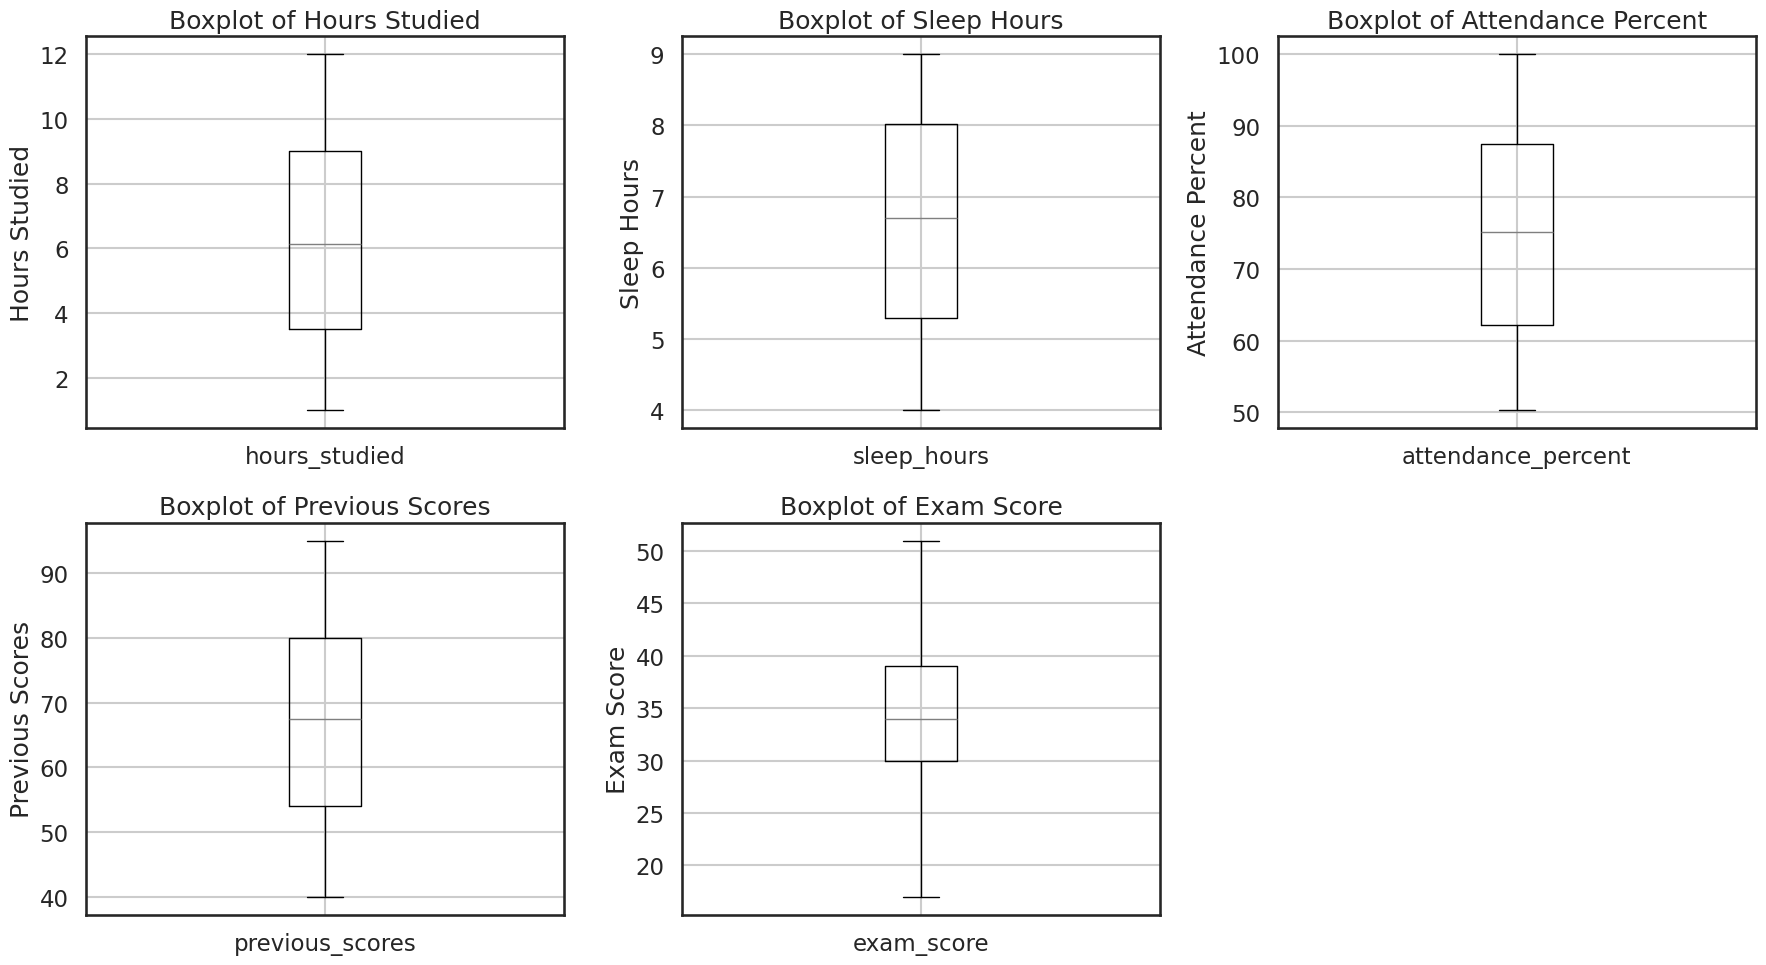

In [ ]:
import matplotlib.pyplot as plt

# Create boxplots for all numerical features
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

numerical_cols = ['hours_studied', 'sleep_hours', 'attendance_percent', 'previous_scores', 'exam_score']

for i, col in enumerate(numerical_cols):
    data.boxplot(column=col, ax=axes[i])
    axes[i].set_title(f'Boxplot of {col.replace('_', ' ').title()}')
    axes[i].set_ylabel(col.replace('_', ' ').title())

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

I use this grid of individual box plots, which is very useful to vizualize the multiple related distributions for different numerical features

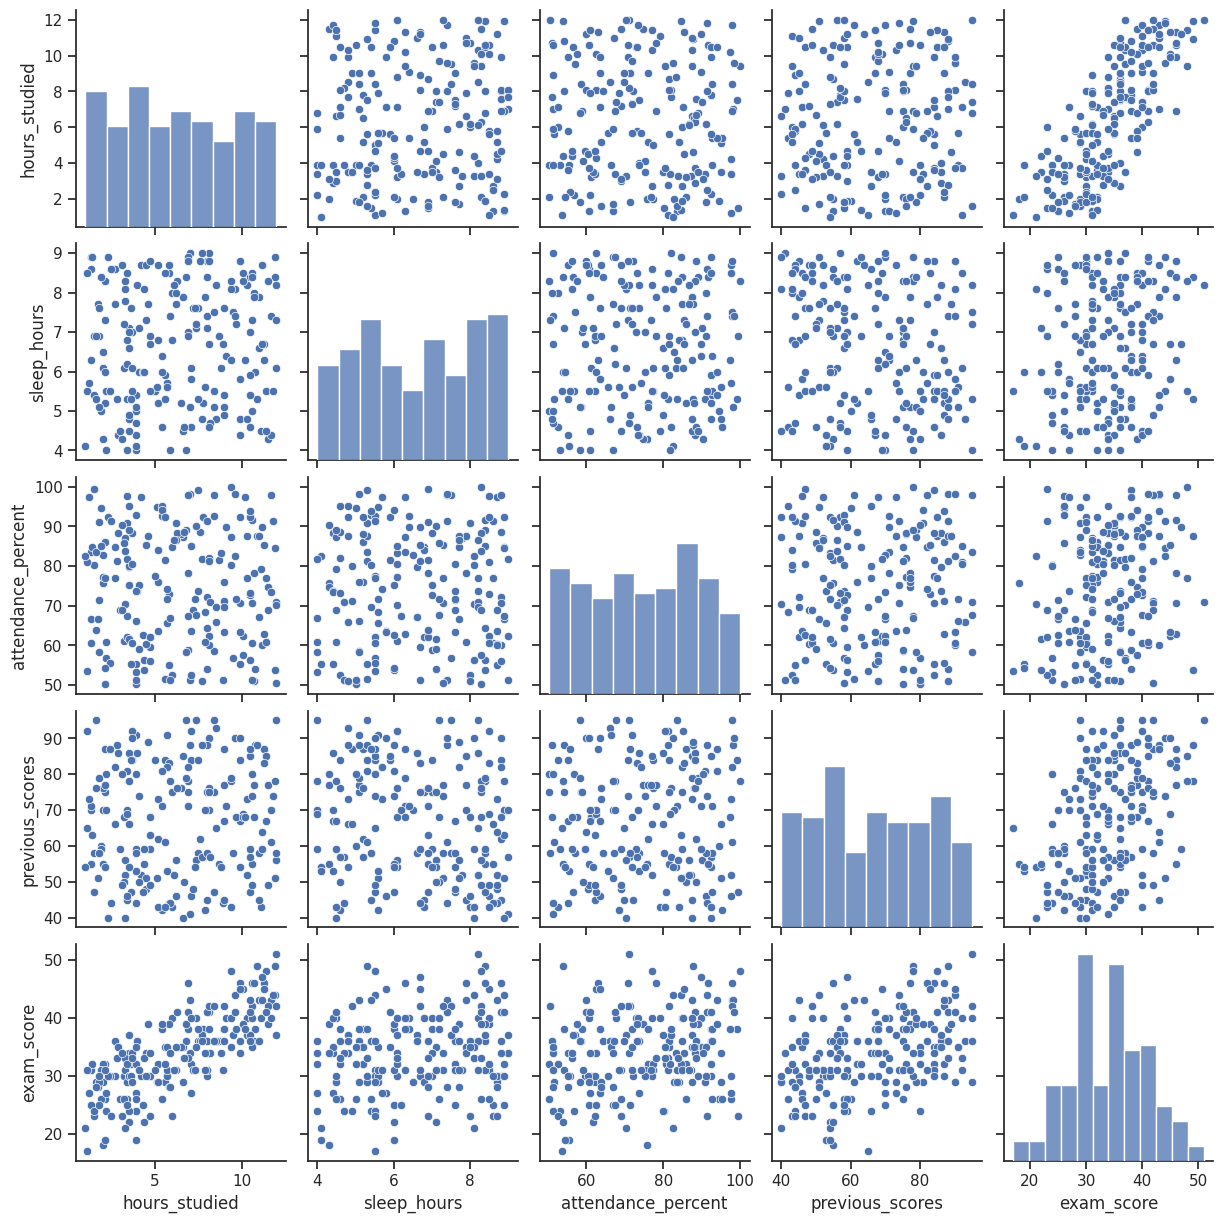

In [125]:
import seaborn as sns
sns.set_theme(style="ticks")
sns.pairplot(data)


I use this pairplot to  examine the relationships between all numerical variables in my dataset.

Conclusion:

The activity gave an overview of the use of different toolsets in machine learning; the main ones were pandas for data manipulation, matplotlib and seaborn for data visualization. We discussed the basic procedures for loading and checking data (including Iris data), cleaning and transforming data (for example, removing prefixes from strings and changing data types).

this activity illustrated the process of descriptive statistics to gain insight into data distributions, calculating data statistics such as mean, median, quartiles, and range. Much of it focused on how to use effective data visualization to uncover relationships in data with scatter plot, to understand distributions with histogram, to display data spread and identify outlier data with box plot, and to explore correlations between multiple variables with pair plot. These visualizations are crucial for gaining insights and understanding the underlying patterns within the data.